# 01 · Chuẩn bị dữ liệu & phân tích hành vi đặt vé (2019–2022)

Notebook này **dựng lại phần phân tích gốc** (`file analyst.ipynb`, 195 cell) gọn hơn, dùng chung code trong `src/` để notebook, pipeline và app cho cùng một kết quả.

**Những điểm đã sửa so với bản gốc** (ghi rõ để minh bạch):

| # | Bản gốc | Sửa lại |
|---|---|---|
| 1 | Cohort "2022" lọc `time < "2020-01-01"` → thực ra vẽ lại dữ liệu 2019 | Lọc đúng năm 2022 (mục 3.6) |
| 2 | Bảng giá trị khách chỉ tính khách có ≥1 giao dịch thành công → **13,701 khách chưa mua được vé bị loại khỏi phân tích** | Tính trên toàn bộ khách (mục 3.5) |
| 3 | Phần "khách có success rate thấp bị lỗi gì" vẽ nhầm `df_error` (toàn bộ khách) thay vì `df_error_0` | So sánh đúng: khách chưa từng mua được vs khách bị lỗi nhưng vẫn mua được (mục 3.7) |
| 4 | Chỉ vẽ 6 mã lỗi, bỏ sót *Payment overdue* | Đủ **7 mã lỗi** |
| 5 | Tuổi tính theo `date.today()` → mỗi lần chạy ra kết quả khác | Tính tại ngày cuối dữ liệu 2022-12-31 |
| 6 | Biểu đồ miền 100% truyền `bank account_pct` hai lần | Mỗi phương thức một lần |

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # để import được thư mục src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, RED, GREY = "#2f6db5", "#d1495b", "#9aa5b1"

In [2]:
from src.data_prep import calc_null_rate, clean_and_join, load_raw, load_tickets
from src import metrics

## 1. Load & kiểm tra dữ liệu

In [3]:
raw = load_raw()
pd.DataFrame({name: tbl.shape for name, tbl in raw.items()}, index=["rows", "cols"]).T

,rows,cols
customer,131400,3
ticket_history,154827,12
device_detail,139902,3
campaign,216,2
status_detail,8,3


In [4]:
calc_null_rate(raw["device_detail"])

,null_count,null_rate
model,7139,0.051029
device_number,1,0.000007
platform,0,0.000000


In [5]:
ticket = raw["ticket_history"]
print("ticket_id trùng:", ticket["ticket_id"].count() - ticket["ticket_id"].nunique())
print("dòng trùng hoàn toàn (keep=False):", ticket.duplicated(keep=False).sum())

ticket_id trùng: 102
dòng trùng hoàn toàn (keep=False): 204


- `device_detail`: 5.1% `model` null → điền `"Unknown"`; 1 dòng `device_number` null → drop vì là khóa join.
- `ticket_history`: 102 `ticket_id` lặp và đều là **dòng trùng hoàn toàn** → `drop_duplicates()`.

## 2. Làm sạch & join
`ticket_history` là bảng gốc, LEFT JOIN lần lượt `customer → campaign → status → device` (logic trong `src/data_prep.py`).

In [6]:
df = load_tickets(use_cache=False)  # chạy lại toàn bộ làm sạch + lưu cache parquet cho các notebook sau
print(f"{len(df):,} lượt thanh toán | {df['is_success'].sum():,} thành công | {df['customer_id'].nunique():,} khách")
print("Khoảng thời gian:", df["time"].min().date(), "→", df["time"].max().date())

154,725 lượt thanh toán | 133,679 thành công | 119,477 khách
Khoảng thời gian: 2019-01-01 → 2022-12-31


In [7]:
raw["status_detail"]

,status_id,description,error_group
0,1,Order successful,NaN
1,-1,Payment overdue,customer
2,-2,Insufficient funds in customer account. Please...,customer
3,-3,No response from your bank,external
4,-4,Password locked due to multiple incorrect atte...,customer
5,-5,Payment failed from bank,external
6,-6,Need verify your account to continue,customer
7,-7,Transaction temporarily limited,internal


Dữ liệu có **7 mã lỗi** chia 3 nhóm: `customer` (lỗi phía khách), `external` (ngân hàng/bên thứ ba), `internal` (hệ thống).

## 3. Phân tích
### 3.1 Chân dung khách hàng

In [8]:
customers = df.drop_duplicates("customer_id")
gender = customers["usergender"].value_counts()
not_verify = customers[customers["usergender"] == "Not verify"]
print(gender.to_frame("customers").assign(share=lambda x: (x["customers"] / x["customers"].sum()).round(3)))
print(f"\n'Not verify' có năm sinh 1970: {(not_verify['dob'].dt.year == 1970).mean():.1%}")

            customers  share
usergender                  
Female          55689  0.466
Male            50873  0.426
Not verify      12915  0.108

'Not verify' có năm sinh 1970: 88.5%


Nhóm **Not verify (~11%)** gần như đều có năm sinh 1970 → hệ thống tự điền khi khách không nhập ngày sinh. Nhóm này bị loại khi phân tích tuổi/thế hệ để không làm lệch phân bổ.

Khách 26–35 tuổi: 54.0%


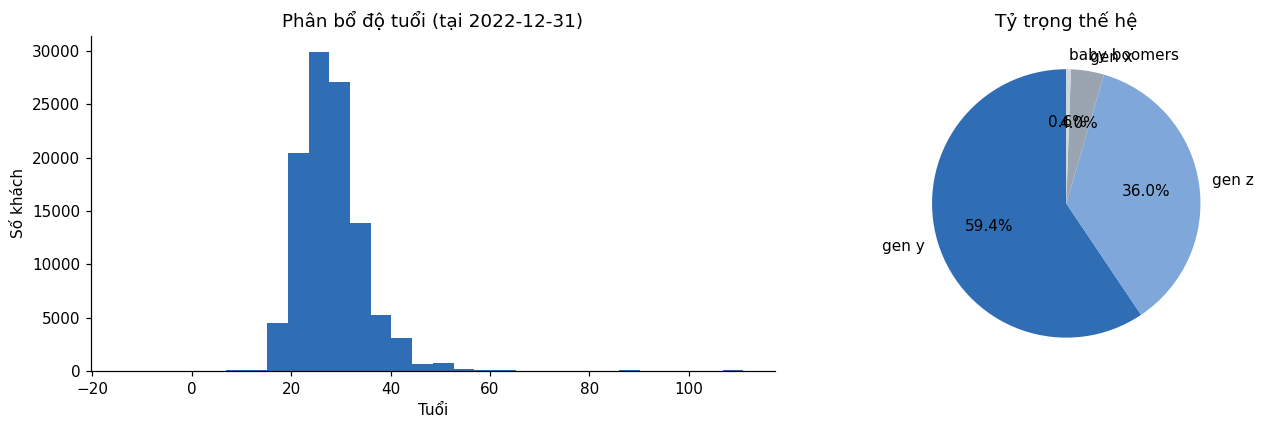

In [9]:
verified = customers[customers["usergender"] != "Not verify"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(verified["age"], bins=30, color=BLUE)
ax[0].set(title="Phân bổ độ tuổi (tại 2022-12-31)", xlabel="Tuổi", ylabel="Số khách")
gen = verified["age_generation"].value_counts()
ax[1].pie(gen, labels=gen.index, autopct="%1.1f%%", startangle=90, colors=[BLUE, "#7fa7d9", GREY, "#cfd6de"])
ax[1].set_title("Tỷ trọng thế hệ")
plt.tight_layout()
print(f"Khách 26–35 tuổi: {verified['age'].between(26, 35).mean():.1%}")

> ⚠️ README trên GitHub ghi *"75% khách 26–35 tuổi"* — tính lại trên dữ liệu chỉ ra **~54%** (tuổi tại ngày cuối dữ liệu). Cần sửa README cho khớp. Gen Y là nhóm chính (~59%), Gen Z ~36%.

### 3.2 Khách mua vé khi nào
Tạo `dim_time` đủ 48 tháng rồi LEFT JOIN để **lộ ra các tháng không có giao dịch (COVID)** thay vì bị ẩn đi.

Tháng không có giao dịch: 3
TB vé/ngày thứ 7–CN so với thứ 2–5: 1.80 lần


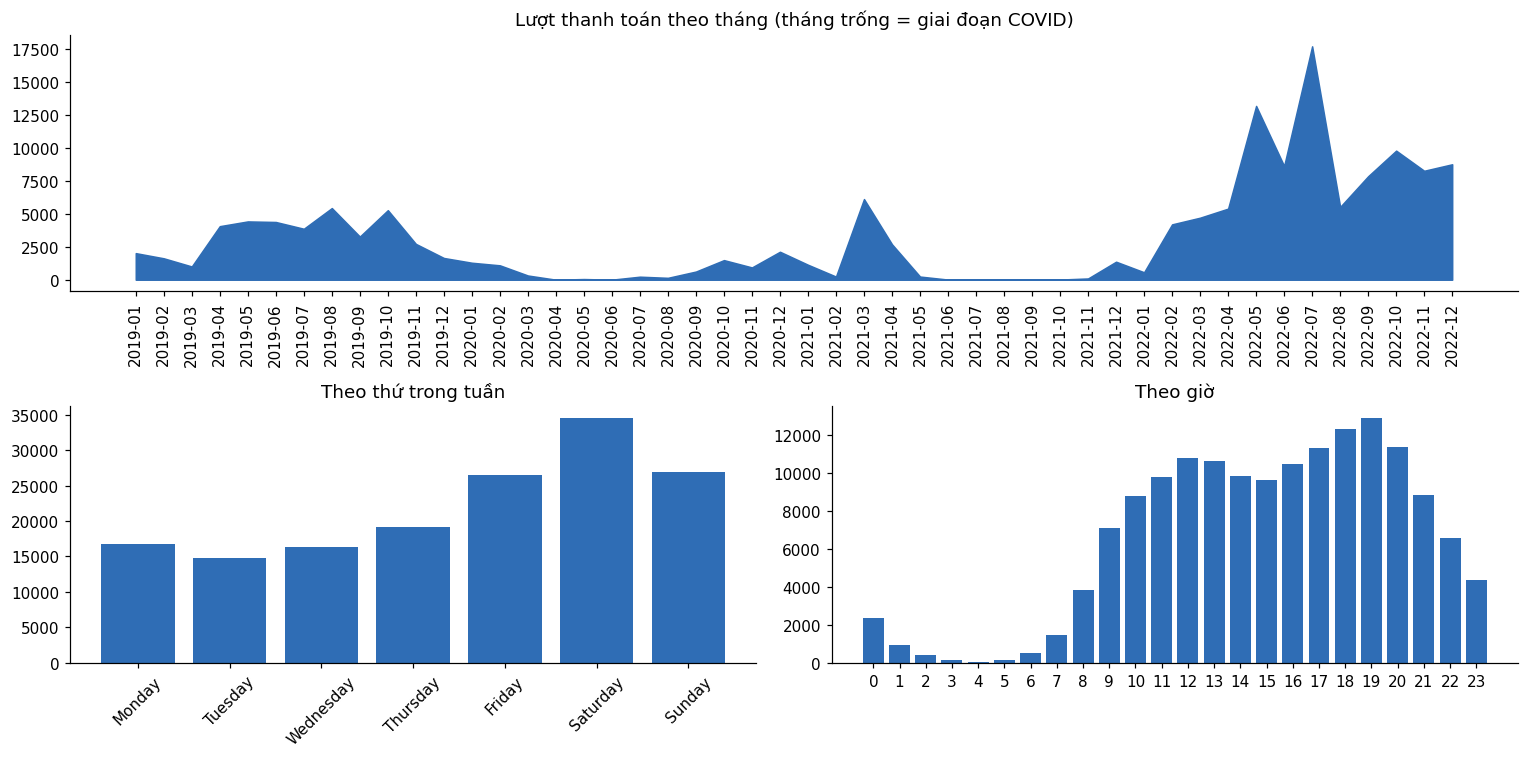

In [10]:
dim_time = pd.DataFrame({"year_month": pd.date_range("2019-01-01", "2022-12-31", freq="MS").strftime("%Y-%m")})
monthly = dim_time.merge(df.groupby("year_month").size().rename("tickets").reset_index(), how="left").fillna(0)
week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday = df["day_name"].value_counts().reindex(week_order)
hourly = df["hour"].value_counts().sort_index()

fig = plt.figure(figsize=(14, 7))
ax1 = plt.subplot(2, 1, 1)
ax1.fill_between(monthly["year_month"], monthly["tickets"], color=BLUE)
ax1.set_title("Lượt thanh toán theo tháng (tháng trống = giai đoạn COVID)")
ax1.tick_params(axis="x", rotation=90)
ax2 = plt.subplot(2, 2, 3); ax2.bar(weekday.index, weekday, color=BLUE); ax2.set_title("Theo thứ trong tuần")
ax2.tick_params(axis="x", rotation=45)
ax3 = plt.subplot(2, 2, 4); ax3.bar(hourly.index, hourly, color=BLUE); ax3.set_title("Theo giờ"); ax3.set_xticks(range(24))
plt.tight_layout()

daily = df.groupby(df["time"].dt.date).size()
dow = pd.to_datetime(pd.Series(daily.index)).dt.dayofweek.values
print("Tháng không có giao dịch:", int((monthly["tickets"] == 0).sum()))
print(f"TB vé/ngày thứ 7–CN so với thứ 2–5: {daily[dow >= 5].mean() / daily[dow <= 3].mean():.2f} lần")

- **3 tháng không có giao dịch nào** (04/2020, 08–09/2021) và nhiều tháng chỉ vài vé đến vài chục vé (rạp đóng cửa vì COVID). Không có `dim_time` thì biểu đồ sẽ nối liền các tháng và che mất khoảng trống.
- Cuối tuần (thứ 7–CN) trung bình **~1.8 lần** ngày thường (thứ 2–5); README ghi 1.5 lần → nên cập nhật.

### 3.3 Nền tảng, thiết bị, phương thức thanh toán

In [11]:
platform = df["platform"].value_counts(normalize=True)
mobile = df[df["platform"] == "mobile"]
os_share = mobile["os_version"].value_counts(normalize=True)
print("Nền tảng:", platform.round(3).to_dict())
print("Hệ điều hành trong giao dịch mobile:", os_share.round(3).to_dict())

Nền tảng: {'mobile': 0.893, 'website': 0.107, 'Unknown': 0.001}
Hệ điều hành trong giao dịch mobile: {'Unknown': 0.475, 'ios': 0.372, 'android and other': 0.153}


- **89% giao dịch qua mobile app.**
- iOS chiếm **37%** giao dịch mobile, nhưng **47.5% không xác định được hệ điều hành** (`devicemodel`/`Unknown`) → con số "55% dùng iOS" trong README không tái lập được; nên ghi kèm hạn chế dữ liệu thiết bị.

,n_tickets,n_failed,failure_rate
paying_method,,,
debit card,15680,4285,0.273278
credit card,19820,4412,0.222603
bank account,52643,10586,0.201090
money in app,66580,1763,0.026479


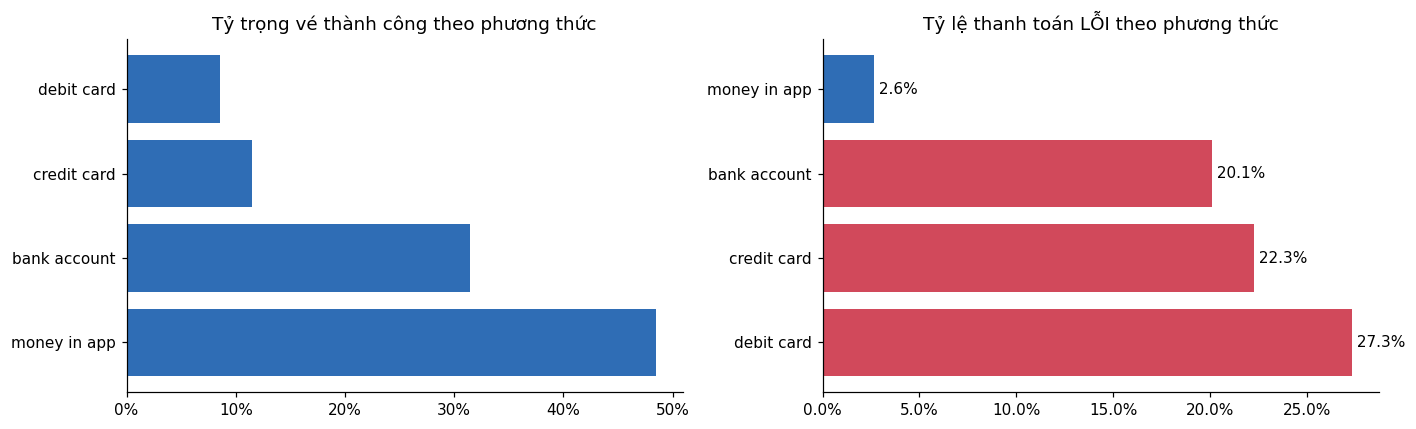

In [12]:
method = metrics.failure_rate_by(df[df["paying_method"] != "other"], "paying_method")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
share = df.loc[df["is_success"] & (df["paying_method"] != "other"), "paying_method"].value_counts(normalize=True)
ax[0].barh(share.index, share, color=BLUE); ax[0].set_title("Tỷ trọng vé thành công theo phương thức")
ax[0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax[1].barh(method.index, method["failure_rate"], color=[RED if r > 0.1 else BLUE for r in method["failure_rate"]])
ax[1].set_title("Tỷ lệ thanh toán LỖI theo phương thức")
ax[1].xaxis.set_major_formatter(mtick.PercentFormatter(1))
for i, r in enumerate(method["failure_rate"]):
    ax[1].text(r, i, f" {r:.1%}", va="center")
plt.tight_layout()
method

**Phát hiện mới (bản gốc chưa có):** tỷ lệ lỗi chênh nhau rất lớn theo phương thức — *money in app* chỉ **2.6%**, trong khi *debit card* **27.3%**, *credit card* 22.3%, *bank account* 20.1%. Đây là **tương quan**, chưa phải nhân quả (ví trong app không phải gọi sang ngân hàng) — sẽ phân tích tiếp ở notebook 02–03.

### 3.4 Khuyến mãi

In [13]:
success = df[df["is_success"]]
promo_per_customer = success[success["type"] == "promotion"].groupby("customer_id").size()
print(f"Vé thành công có khuyến mãi: {success['type'].eq('promotion').mean():.1%}")
print(f"Khách (có mua thành công) từng dùng khuyến mãi: {len(promo_per_customer) / success['customer_id'].nunique():.1%}")
print(f"... trong đó chỉ dùng đúng 1 lần: {(promo_per_customer == 1).mean():.1%}")
print(f"Vé khuyến mãi thuộc 'direct discount': {(success.loc[success['type'] == 'promotion', 'campaign_type'] == 'direct discount').mean():.1%}")

Vé thành công có khuyến mãi: 58.7%
Khách (có mua thành công) từng dùng khuyến mãi: 65.2%
... trong đó chỉ dùng đúng 1 lần: 88.9%
Vé khuyến mãi thuộc 'direct discount': 87.2%


Khớp với bản gốc: **~65% khách từng dùng khuyến mãi, ~89% trong số đó chỉ dùng 1 lần**, và khuyến mãi chủ yếu là *direct discount* (~87%).

### 3.5 Giá trị khách hàng — tính trên TOÀN BỘ khách
Bản gốc tính chỉ số từ giao dịch thành công rồi mới ghép phần lỗi, nên khách **chưa từng mua thành công** biến mất khỏi bảng. Sửa lại: gom trên mọi lượt thanh toán.

In [14]:
customer_value = (
    df.assign(
        money_success=df["original_price"].where(df["is_success"], 0),
        discount_success=df["discount_value"].where(df["is_success"], 0),
    )
    .groupby("customer_id")
    .agg(
        n_total=("ticket_id", "count"),
        n_success=("is_success", "sum"),
        s_money=("money_success", "sum"),
        s_discount=("discount_success", "sum"),
    )
)
customer_value["success_rate"] = customer_value["n_success"] / customer_value["n_total"]
print(f"Khách có success_rate = 0 (chưa từng mua được vé): {(customer_value['success_rate'] == 0).sum():,}")
customer_value["n_success"].clip(upper=10).value_counts().sort_index().rename("customers").to_frame().T

Khách có success_rate = 0 (chưa từng mua được vé): 13,701


n_success,0,1,2,3,4,5,6,7,8,9,10
customers,13701,87921,12902,3145,1017,380,168,92,47,30,74


**13,701 khách (11.5% tổng khách) chưa từng mua được vé nào** — nhóm này không xuất hiện trong phân tích gốc. Đây là điểm xuất phát của notebook 02.

### 3.6 Cohort retention — 2019 vs 2022 (đã sửa bộ lọc năm)

2019: retention tháng 1 trung bình = 4.3%, tháng 3 = 3.6%


2022: retention tháng 1 trung bình = 3.7%, tháng 3 = 3.3%


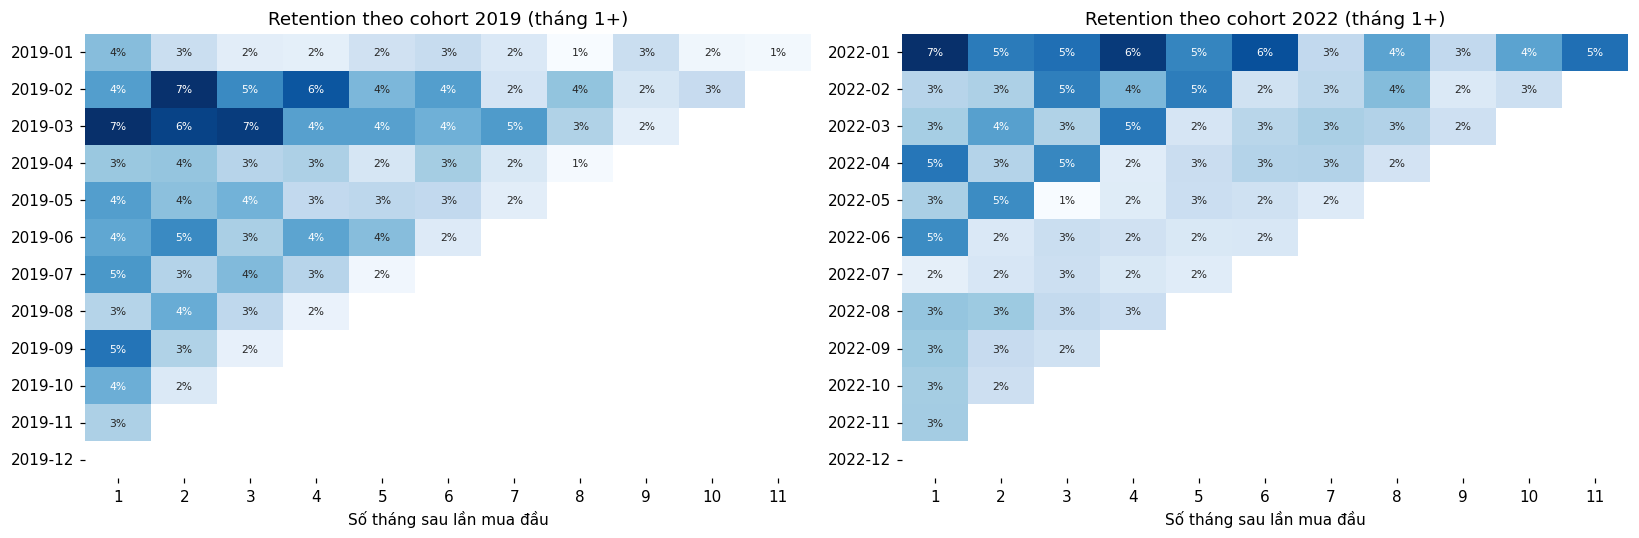

In [15]:
from operator import attrgetter


def cohort_matrix(data, year):
    x = data[data["is_success"] & (data["year"] == year)].copy()
    x["first_month"] = x.groupby("customer_id")["time"].transform("min").dt.to_period("M")
    x["k"] = (x["time"].dt.to_period("M") - x["first_month"]).apply(attrgetter("n"))
    counts = x.groupby(["first_month", "k"])["customer_id"].nunique().unstack()
    return counts.div(counts[0], axis=0), counts[0]


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, year in zip(axes, [2019, 2022]):
    matrix, size = cohort_matrix(df, year)
    sns.heatmap(matrix.iloc[:, 1:], annot=True, fmt=".0%", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 7})
    ax.set(title=f"Retention theo cohort {year} (tháng 1+)", xlabel="Số tháng sau lần mua đầu", ylabel="")
    print(f"{year}: retention tháng 1 trung bình = {matrix[1].mean():.1%}, tháng 3 = {matrix[3].mean():.1%}")
plt.tight_layout()

Sau khi sửa bộ lọc, retention tháng 1 là **4.3% (2019)** và **3.7% (2022)**: thấp ở cả hai năm, và 2022 còn thấp hơn một chút **dù 2022 chạy khuyến mãi nhiều hơn**. Kết luận "retention không cải thiện" của bản gốc vẫn đúng hướng, nhưng giờ đã dựa trên dữ liệu 2022 thật.

### 3.7 Tỷ lệ thanh toán thành công & lỗi

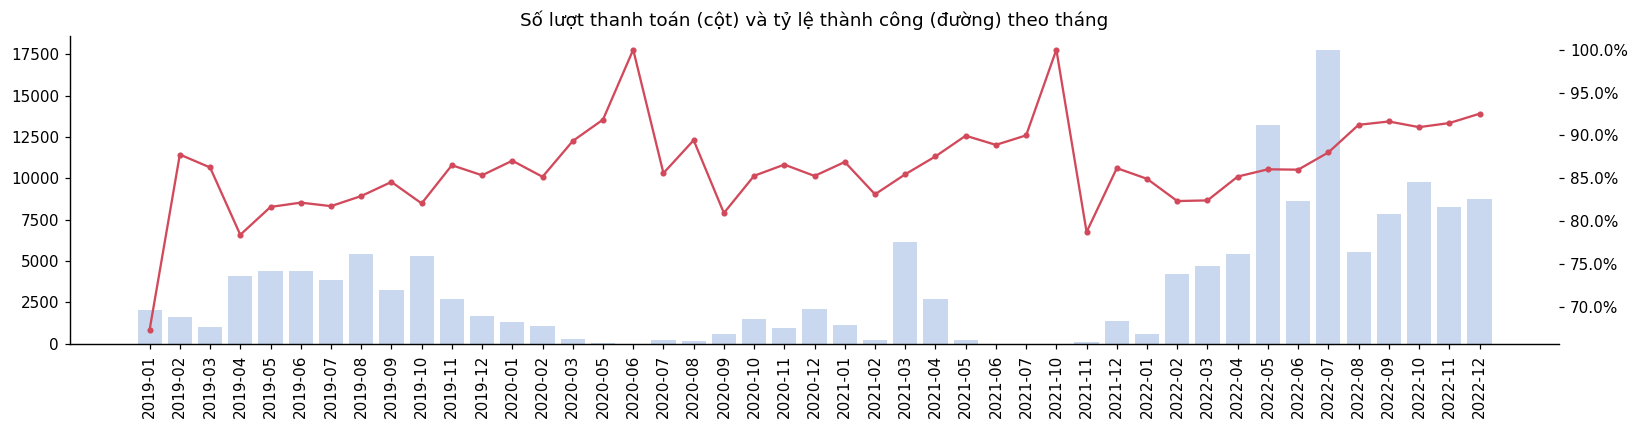

In [16]:
sr = df.groupby("year_month").agg(tickets=("ticket_id", "count"), success_rate=("is_success", "mean"))
fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.bar(sr.index, sr["tickets"], color="#c9d8ee")
ax1.tick_params(axis="x", rotation=90)
ax2 = ax1.twinx()
ax2.plot(sr.index, sr["success_rate"], color=RED, marker="o", ms=3)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.set_title("Số lượt thanh toán (cột) và tỷ lệ thành công (đường) theo tháng")
plt.tight_layout()

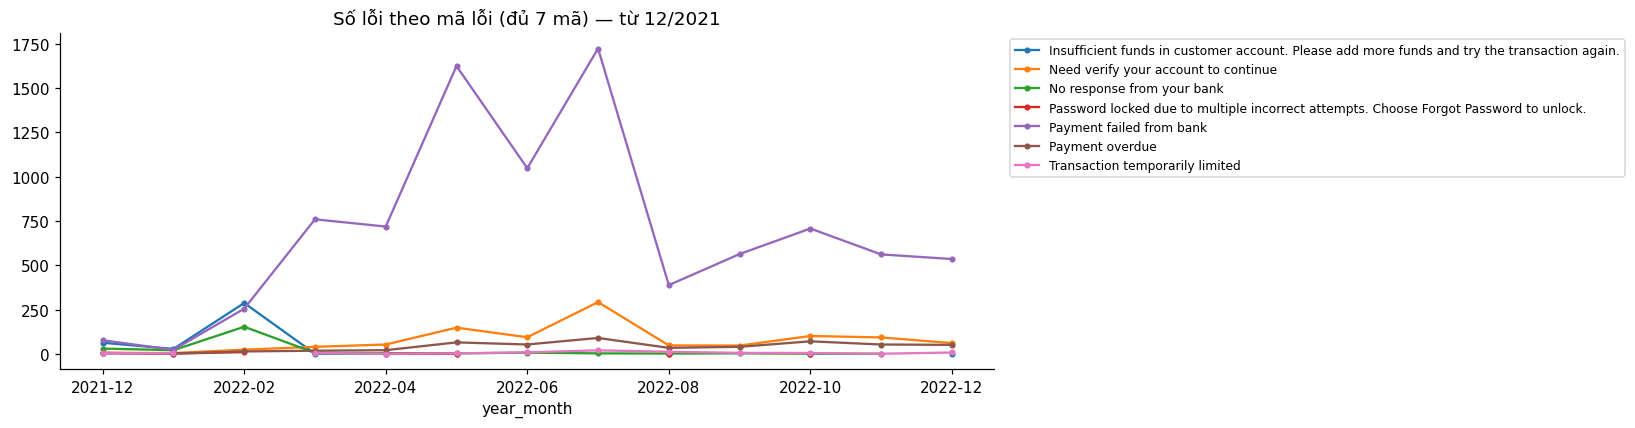

In [17]:
errors = df[df["is_failed"]].pivot_table(index="year_month", columns="description", values="ticket_id", aggfunc="count")
errors.loc["2021-12":].plot(figsize=(15, 4), marker="o", ms=3, title="Số lỗi theo mã lỗi (đủ 7 mã) — từ 12/2021")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

In [18]:
never = customer_value[customer_value["success_rate"] == 0].index
recovered = customer_value[customer_value["success_rate"].between(0, 1, inclusive="neither")].index
failed_tx = df[df["is_failed"]]
compare = {}
for label, ids in [(f"chưa từng mua được ({len(never):,} khách)", never), (f"lỗi nhưng vẫn mua được ({len(recovered):,} khách)", recovered)]:
    group = failed_tx[failed_tx["customer_id"].isin(ids)]
    compare[label] = pd.concat([group["error_group"].value_counts(normalize=True), group["paying_method"].value_counts(normalize=True)])
pd.DataFrame(compare).round(3)

,"chưa từng mua được (13,701 khách)","lỗi nhưng vẫn mua được (5,465 khách)"
bank account,0.522,0.458
credit card,0.180,0.281
customer,0.255,0.215
debit card,0.208,0.193
external,0.732,0.777
internal,0.014,0.008
money in app,0.090,0.068


- Lỗi **external (ngân hàng)** chiếm ~3/4 số lỗi và tăng vọt từ tháng 3/2022 — khách không tự khắc phục được.
- Khách *bỏ đi hẳn* và khách *vẫn mua được* gặp **cùng loại lỗi** với tỷ trọng gần như nhau (external 73% vs 78%). Khác biệt không nằm ở loại lỗi, mà ở việc **có thử lại hay không** → cần chủ động liên hệ lại khách bị lỗi. Notebook 04 dựng hệ thống cảnh báo sớm cho đúng loại sự cố này.

## Tóm tắt
| Chủ đề | Kết quả |
|---|---|
| Quy mô | 154,725 lượt thanh toán · 133,679 thành công · 119,477 khách · 2019–2022 |
| Kênh | 89% qua mobile app |
| Thời gian | Cuối tuần ~1.8 lần ngày thường; nhiều tháng trống do COVID |
| Khuyến mãi | ~65% khách dùng khuyến mãi, ~89% chỉ dùng 1 lần; retention tháng 1 chỉ 3.7–4.3% |
| Thanh toán | Tỷ lệ lỗi: money in app 2.6% vs thẻ/ngân hàng 20–27% |
| **Bị bỏ sót ở bản gốc** | **13,701 khách chưa từng mua được vé** → notebook 02 |